# BrushCue Example: Circle Crop

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/circle_crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/circle-crop

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


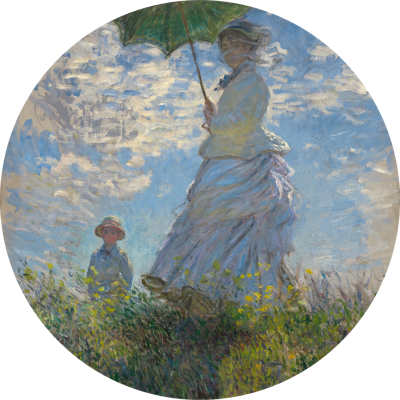

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
input_bounds = input_image.bounds()
input_width = input_bounds.width()
input_height = input_bounds.height()
diameter = bc.Float.min(input_width, input_height)
position = 0.5
crop_x = input_bounds.min_x() + ((input_width - diameter) * position)
crop_y = input_bounds.min_y() + ((input_height - diameter) * position)
circle_center = bc.Point2f.from_components(
    (crop_x + (diameter * 0.5)), (crop_y + (diameter * 0.5))
)
mask_color = bc.ProfiledColor.from_rgba_srgb(
    bc.RGBAColor.from_components(1.0, 1.0, 1.0, 1.0)
)
mask_style = bc.RenderStyle.fill_only(bc.Fill.solid(mask_color))
mask_painter = bc.Painter.new().add_ellipse_with_render_style(
    circle_center,
    bc.Vector2f.from_components(diameter, diameter),
    0.0,
    mask_style,
    bc.Object.to_list(bc.Transform2.identity()),
)
circle_mask = bc.Composition.painter(mask_painter)
crop_bounds = bc.Bounds2f.from_x_y_width_height(crop_x, crop_y, diameter, diameter)
graph = circle_mask.blend_stencil(
    input_image.crop(crop_bounds), bc.Transform2.identity()
).crop(crop_bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
